<a href="https://colab.research.google.com/github/Razan445/IT326-Project/blob/main/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
raw_df = df.copy()

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
stat_summary = df[numeric_cols].describe().T

stat_summary['IQR'] = stat_summary['75%'] - stat_summary['25%']

print("--- Statistical and Five-Number Summaries ---")
display(stat_summary[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'IQR']])

--- Statistical and Five-Number Summaries ---


,count,mean,std,min,25%,50%,75%,max,IQR
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000,445.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000,1.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000,17.8750
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000,1.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000,0.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292,23.0896


### Statistical & Five-Number Summary Interpretation
- **`Age`:** Has a mean of ~29.7 years, a median (50%) of 28 years, and an IQR of 17.75 years, showing a relatively normal concentration around adults aged 20–38.
- **`Fare`:** Has a high standard deviation (std = 49.69) with a mean of 32.20 and a maximum of 512.32, which indicates a strongly right-skewed distribution with extreme high values.

In [4]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage (%)': missing_percent
})

print("--- Missing Values Summary ---")
display(missing_table[missing_table['Missing Count'] > 0])

--- Missing Values Summary ---


,Missing Count,Percentage (%)
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


### Missing Values Analysis & Preprocessing Needs
- **`Cabin`:** Contains **687 missing values (77.10%)**. Due to this high missing rate, imputation is not recommended as it may introduce noise, suggesting the attribute should be dropped.
- **`Age`:** Contains **177 missing values (19.87%)**. Since Age is an important feature, it requires imputation using central metrics (e.g., median imputed by passenger class/gender).
- **`Embarked`:** Contains only **2 missing values (0.22%)**, which can easily be imputed using the mode (most frequent port).

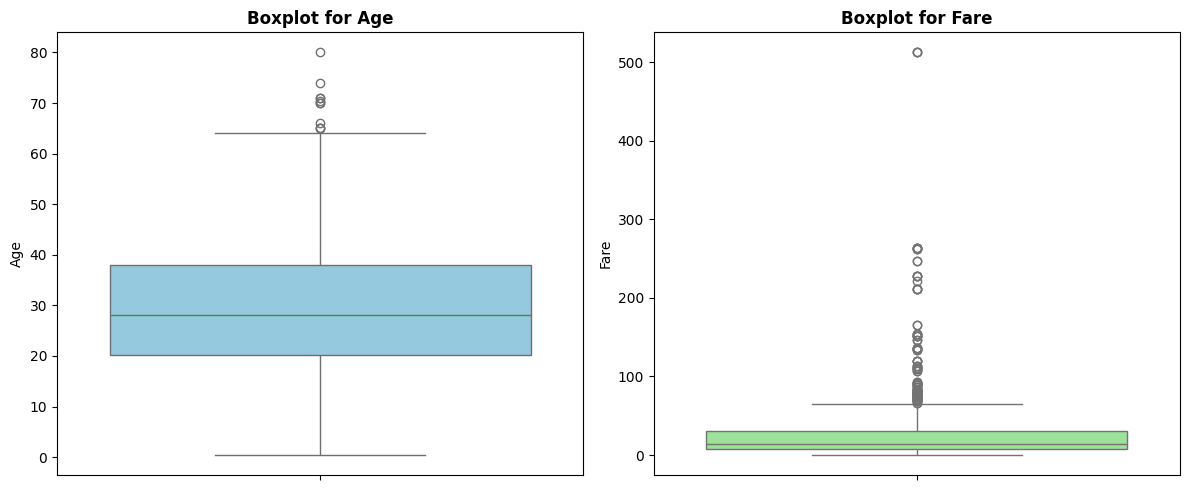

Age Outliers Count: 11 (Threshold: > 64.81)
Fare Outliers Count: 116 (Threshold: > 65.63)


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Outliers Extraction and Boxplots for Numeric Attributes
plt.figure(figsize=(12, 5))

# Boxplot for Age
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Age'], color='skyblue')
plt.title('Boxplot for Age', fontsize=12, fontweight='bold')

# Boxplot for Fare
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Fare'], color='lightgreen')
plt.title('Boxplot for Fare', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Detect Outliers programmatically using IQR
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

age_outliers_cnt, age_low, age_high = detect_outliers_iqr(df['Age'].dropna())
fare_outliers_cnt, fare_low, fare_high = detect_outliers_iqr(df['Fare'].dropna())

print(f"Age Outliers Count: {age_outliers_cnt} (Threshold: > {age_high:.2f})")
print(f"Fare Outliers Count: {fare_outliers_cnt} (Threshold: > {fare_high:.2f})")

### Outliers Analysis & Need for Preprocessing
- **`Fare` Boxplot Explanation:** The plot indicates a severe presence of extreme upper outliers (116 data points above 65.63). This demonstrates that raw Fare values will skew distance-based machine learning algorithms. Thus, **normalization (such as Log Transformation or Min-Max / Standard Scaling)** is strongly needed in the preprocessing stage to handle noise and scale the data properly.
- **`Age` Boxplot Explanation:** Shows a small cluster of upper outliers (older passengers above 64.81 years). Since these are realistic historical values rather than errors, **discretization (binning ages into categorical groups)** or robust scaling can be utilized.